# BÁO CÁO PHÂN TÍCH VÀ KHÁM PHÁ DỮ LIỆU (EDA) & TIỀN XỬ LÝ
## Phân hệ: Người 1 — Dataset & EDA
### Đề tài: Kết hợp KolektorSDD2 + Magnetic-tile-defect-datasets.-master (Combined_Surface_Defect_YOLO)

---
### Danh mục nhiệm vụ hoàn thành:
- [x] **Dataset Audit**: Quét toàn diện, ghép cặp ảnh - mask cho cả KolektorSDD2 (3,337 ảnh) và Magnetic-tile-defect-datasets.-master (1,344 ảnh).
- [x] **Image Hashing Deduplication nâng cấp**: Thuật toán dHash 256-bit (16x16) lọc trùng độc lập nội bộ từng dataset (Intra-dataset), bảo toàn 100% mẫu khuyết tật hiếm.
- [x] **Positive / Negative Distribution**: Đánh giá phân bố giữa ảnh có khuyết tật và ảnh bình thường.
- [x] **Image Size & Aspect Ratio**: Phân tích kích thước ảnh ($W, H$) và tỷ lệ khung hình.
- [x] **Mask Integrity**: Đảm bảo tính toàn vẹn 1-1 giữa ảnh và ground truth mask.
- [x] **Defect Area Distribution**: Phân tích diện tích pixel và tỷ lệ % diện tích khuyết tật.
- [x] **Small / Medium / Large Definition**: Phân loại quy mô khuyết tật theo chuẩn COCO ($<32^2$, $32^2-96^2$, $>96^2$).
- [x] **Visualization**: Trực quan hóa ảnh gốc kèm Ground Truth Mask và YOLO Bounding Box.
- [x] **Stratified Split & Train Augmentation**: Phân chia 70% Train - 15% Val - 15% Test và tăng cường dữ liệu chỉ cho tập Train.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

# Giải nén KolektorSDD2
!unzip -q "/content/drive/MyDrive/Colab Notebooks/KolektorSDD2.zip" -d "/content/KolektorSDD2"
# Giải nén Magnetic Tile Defect
!unzip -q "/content/drive/MyDrive/Colab Notebooks/Magnetic-tile-defect-datasets.-master.zip" -d "/content/"

print("Đã giải nén xong!")

## 1. Khởi tạo môi trường và Thư viện

In [5]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Import module dataset tối ưu
from dataset import (
    DatasetAuditor, ImageHasher, DefectExtractor,
    DatasetSplitter, TrainAugmentor, SampleRecord
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

PROJECT_DIR = Path(".").resolve()
KOLEKTOR_DIR = PROJECT_DIR / "KolektorSDD2"
OUTPUT_YOLO_DIR = PROJECT_DIR / "Combined_Surface_Defect_YOLO"
FIGURES_DIR = PROJECT_DIR / "eda_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Thư mục dự án: {PROJECT_DIR}")

Thư mục dự án: /content


## 2. Dataset Audit & Mask Integrity Check (KolektorSDD2 + Magnetic Tile)
Tiến hành quét cả 2 bộ dữ liệu: tự động ghép cặp ảnh chụp với ground truth mask tương ứng và kiểm tra tính toàn vẹn (kích thước, định dạng, file hỏng).

In [6]:
# 1. Quét KolektorSDD2
kolektor_samples = DatasetAuditor.scan_kolektor(KOLEKTOR_DIR)
print(f"-> Quét xong KolektorSDD2: {len(kolektor_samples):,} ảnh")

# 2. Quét Magnetic-tile-defect-datasets.-master (tự động giải nén ZIP nếu có)
mt_dir = DatasetAuditor.locate_magnetic_tile_dir(PROJECT_DIR)
mt_samples = []
if mt_dir:
    print(f"-> Tìm thấy thư mục Magnetic Tile: {mt_dir.name}")
    mt_samples = DatasetAuditor.scan_magnetic_tile(mt_dir)
    print(f"-> Quét xong Magnetic Tile: {len(mt_samples):,} ảnh")
else:
    print("-> [Lưu ý] Chưa tìm thấy thư mục/file ZIP Magnetic-tile-defect-datasets.-master!")

raw_samples = kolektor_samples + mt_samples
print(f"\n===> Tổng cộng thu thập được: {len(raw_samples):,} mẫu ảnh")

# Kiểm tra tính toàn vẹn
status_counts = pd.Series([s.integrity_status for s in raw_samples]).value_counts()
print("\n--- KẾT QUẢ KIỂM TRA TÍNH TOÀN VẸN (MASK INTEGRITY) ---")
print(status_counts)

-> Quét xong KolektorSDD2: 3,337 ảnh
-> Tìm thấy thư mục Magnetic Tile: Magnetic-tile-defect-datasets.-master
---> Đang quét toàn diện thư mục Magnetic Tile: Magnetic-tile-defect-datasets.-master...
  [OK] Đã quét thành công 1,344 ảnh thực tế từ Magnetic Tile.
-> Quét xong Magnetic Tile: 1,344 ảnh

===> Tổng cộng thu thập được: 4,681 mẫu ảnh

--- KẾT QUẢ KIỂM TRA TÍNH TOÀN VẸN (MASK INTEGRITY) ---
OK                     3727
OK (Clean/Negative)     954
Name: count, dtype: int64


## 3. Lọc trùng lặp thông minh (dHash 256-bit, Intra-dataset)
Áp dụng Difference Hash độ phân giải cao 256-bit (16x16) và lọc độc lập trong từng nguồn dữ liệu để không xóa nhầm ảnh của Magnetic Tile.

In [7]:
print("Đang tiến hành lọc ảnh trùng lặp qua dHash 256-bit...")
unique_samples, dup_stats = ImageHasher.deduplicate(raw_samples, pos_threshold=2, neg_threshold=4)

print("Thống kê loại bỏ ảnh trùng lặp:")
for src, cnt in dup_stats.items():
    print(f"  + Nguồn {src}: {cnt:,} ảnh trùng")
print(f"Số ảnh ban đầu  : {len(raw_samples):,}")
print(f"Số ảnh giữ lại  : {len(unique_samples):,}")

Đang tiến hành lọc ảnh trùng lặp qua dHash 256-bit...
Thống kê loại bỏ ảnh trùng lặp:
  + Nguồn KolektorSDD2: 0 ảnh trùng
  + Nguồn MagneticTile: 82 ảnh trùng
Số ảnh ban đầu  : 4,681
Số ảnh giữ lại  : 4,599


## 4. Xây dựng Bảng thống kê Dataset (dataset_statistics.csv)

In [8]:
records = []
for s in unique_samples:
    total_area = sum(d.area_pixels for d in s.defects)
    rel_area = sum(d.relative_area for d in s.defects)
    cats = list(set(d.category for d in s.defects))
    cat_str = ", ".join(cats) if cats else "None"

    records.append({
        "sample_id": s.sample_id,
        "dataset_source": s.dataset_source,
        "filename": s.image_path.name,
        "width": s.width,
        "height": s.height,
        "channels": s.channels,
        "aspect_ratio": s.aspect_ratio,
        "has_defect": s.has_defect,
        "num_defects": s.num_defects,
        "total_defect_area_px": total_area,
        "relative_defect_area_pct": round(rel_area, 4),
        "defect_size_categories": cat_str,
        "split": s.split,
        "integrity_status": s.integrity_status
    })

df = pd.DataFrame(records)
csv_out = PROJECT_DIR / "dataset_statistics.csv"
df.to_csv(csv_out, index=False, encoding='utf-8-sig')
print(f"Đã xuất bảng dữ liệu thống kê ra: {csv_out}")
df.head()

Đã xuất bảng dữ liệu thống kê ra: /content/dataset_statistics.csv


,sample_id,dataset_source,filename,width,height,channels,aspect_ratio,has_defect,num_defects,total_defect_area_px,relative_defect_area_pct,defect_size_categories,split,integrity_status
0,ksdd2_10021,KolektorSDD2,10021.png,228,649,3,0.3513,True,1,3209,2.1687,Medium,train,OK
1,ksdd2_10028,KolektorSDD2,10028.png,229,643,3,0.3561,True,1,899,0.6105,Small,train,OK
2,ksdd2_10045,KolektorSDD2,10045.png,211,638,3,0.3307,True,1,14,0.0104,Small,train,OK
3,ksdd2_10047,KolektorSDD2,10047.png,231,637,3,0.3626,True,1,19430,13.2045,Large,train,OK
4,ksdd2_10057,KolektorSDD2,10057.png,230,640,3,0.3594,True,1,1631,1.1080,Medium,train,OK


## 5. Phân tích phân phối Positive vs Negative & Nguồn Dataset

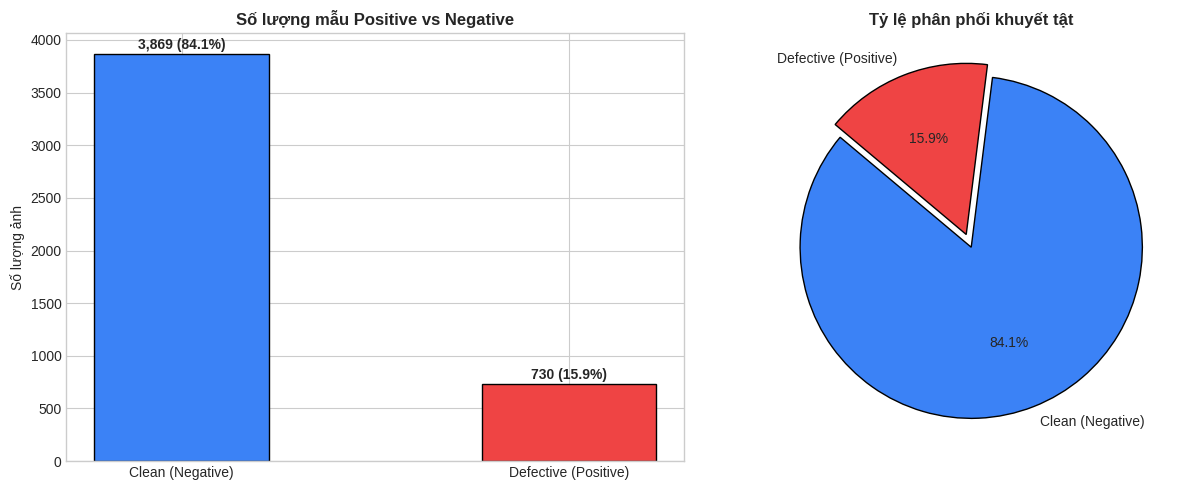

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pos_counts = df['has_defect'].value_counts()
labels = ['Clean (Negative)', 'Defective (Positive)']
vals = [pos_counts.get(False, 0), pos_counts.get(True, 0)]

bars = axes[0].bar(labels, vals, color=['#3b82f6', '#ef4444'], width=0.45, edgecolor='black')
for b in bars:
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2.0, h + 20, f"{h:,} ({h/len(df)*100:.1f}%)",
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title("Số lượng mẫu Positive vs Negative", fontweight='bold')
axes[0].set_ylabel("Số lượng ảnh")

axes[1].pie(vals, labels=labels, autopct='%1.1f%%', startangle=140,
            colors=['#3b82f6', '#ef4444'], explode=(0, 0.08),
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title("Tỷ lệ phân phối khuyết tật", fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_positive_negative_distribution.png", dpi=300)
plt.show()

## 6. Phân tích Kích thước ảnh & Tỷ lệ khung hình (Image Size & Aspect Ratio)

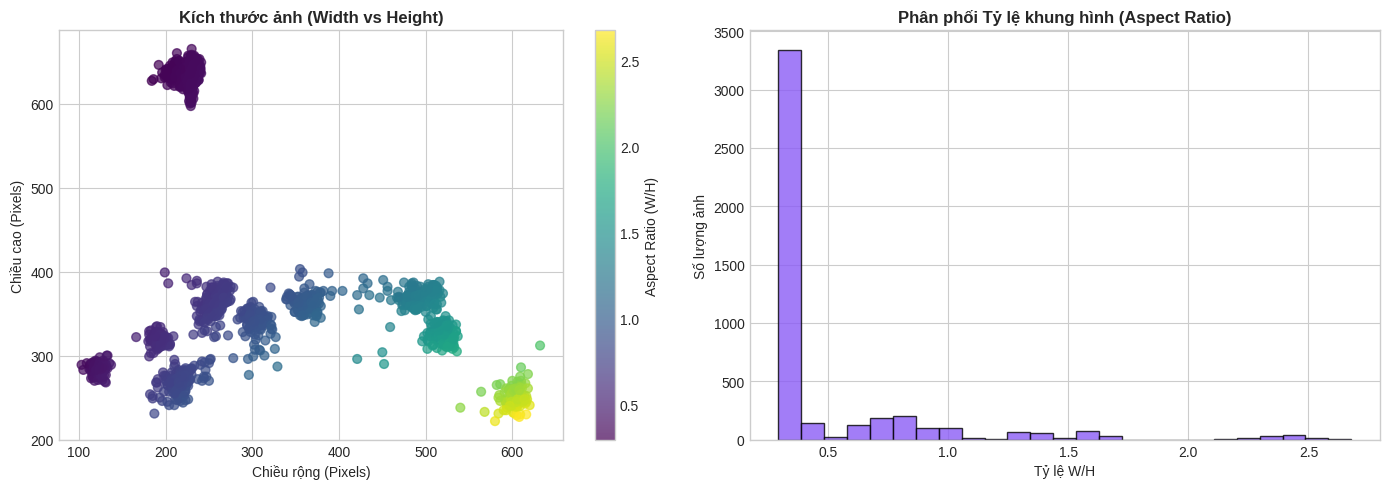

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(df['width'], df['height'], c=df['aspect_ratio'], cmap='viridis', s=40, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Aspect Ratio (W/H)')
axes[0].set_title("Kích thước ảnh (Width vs Height)", fontweight='bold')
axes[0].set_xlabel("Chiều rộng (Pixels)")
axes[0].set_ylabel("Chiều cao (Pixels)")

axes[1].hist(df['aspect_ratio'], bins=25, color='#8b5cf6', edgecolor='black', alpha=0.8)
axes[1].set_title("Phân phối Tỷ lệ khung hình (Aspect Ratio)", fontweight='bold')
axes[1].set_xlabel("Tỷ lệ W/H")
axes[1].set_ylabel("Số lượng ảnh")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_image_dimensions_aspect_ratio.png", dpi=300)
plt.show()

## 7. Định nghĩa & Phân loại quy mô khuyết tật: Small / Medium / Large (COCO Standard)
Áp dụng chuẩn quốc tế **COCO Object Detection Benchmark**:
- **Small (Nhỏ)**: Diện tích $< 32^2 = 1,024 \text{ px}^2$.
- **Medium (Trung bình)**: $32^2 \le \text{Diện tích} \le 96^2 = 9,216 \text{ px}^2$.
- **Large (Lớn)**: Diện tích $> 96^2 = 9,216 \text{ px}^2$.

Tổng số bounding box khuyết tật: 830


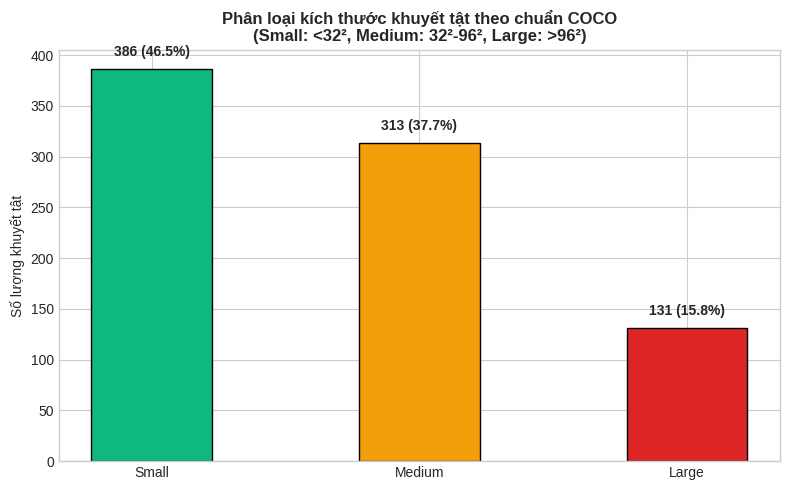

In [11]:
all_cats = []
all_areas = []
for s in unique_samples:
    for d in s.defects:
        all_cats.append(d.category)
        all_areas.append(d.area_pixels)

print(f"Tổng số bounding box khuyết tật: {len(all_cats):,}")
cat_counts = pd.Series(all_cats).value_counts()[['Small', 'Medium', 'Large']].dropna()

plt.figure(figsize=(8, 5))
bars = plt.bar(cat_counts.index, cat_counts.values, color=['#10b981', '#f59e0b', '#dc2626'], width=0.45, edgecolor='black')
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2.0, h + 10, f"{h:,} ({h/len(all_cats)*100:.1f}%)",
             ha='center', va='bottom', fontweight='bold')

plt.title("Phân loại kích thước khuyết tật theo chuẩn COCO\n(Small: <32², Medium: 32²-96², Large: >96²)", fontweight='bold')
plt.ylabel("Số lượng khuyết tật")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_defect_size_categories.png", dpi=300)
plt.show()

## 8. Phân tích phân phối diện tích khuyết tật (Defect Area Distribution)

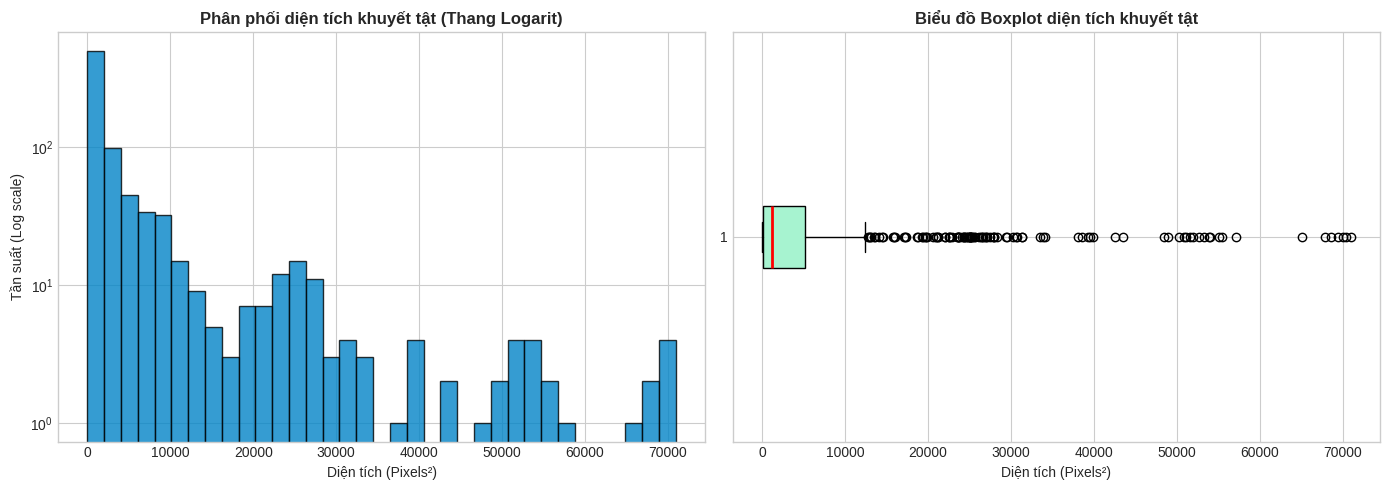

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_areas, bins=35, color='#0284c7', edgecolor='black', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title("Phân phối diện tích khuyết tật (Thang Logarit)", fontweight='bold')
axes[0].set_xlabel("Diện tích (Pixels²)")
axes[0].set_ylabel("Tần suất (Log scale)")

axes[1].boxplot(all_areas, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#a7f3d0', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Biểu đồ Boxplot diện tích khuyết tật", fontweight='bold')
axes[1].set_xlabel("Diện tích (Pixels²)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_defect_area_distribution.png", dpi=300)
plt.show()

## 9. Trực quan hóa Mẫu ảnh (Visualization: Image + Mask + YOLO Bounding Box)

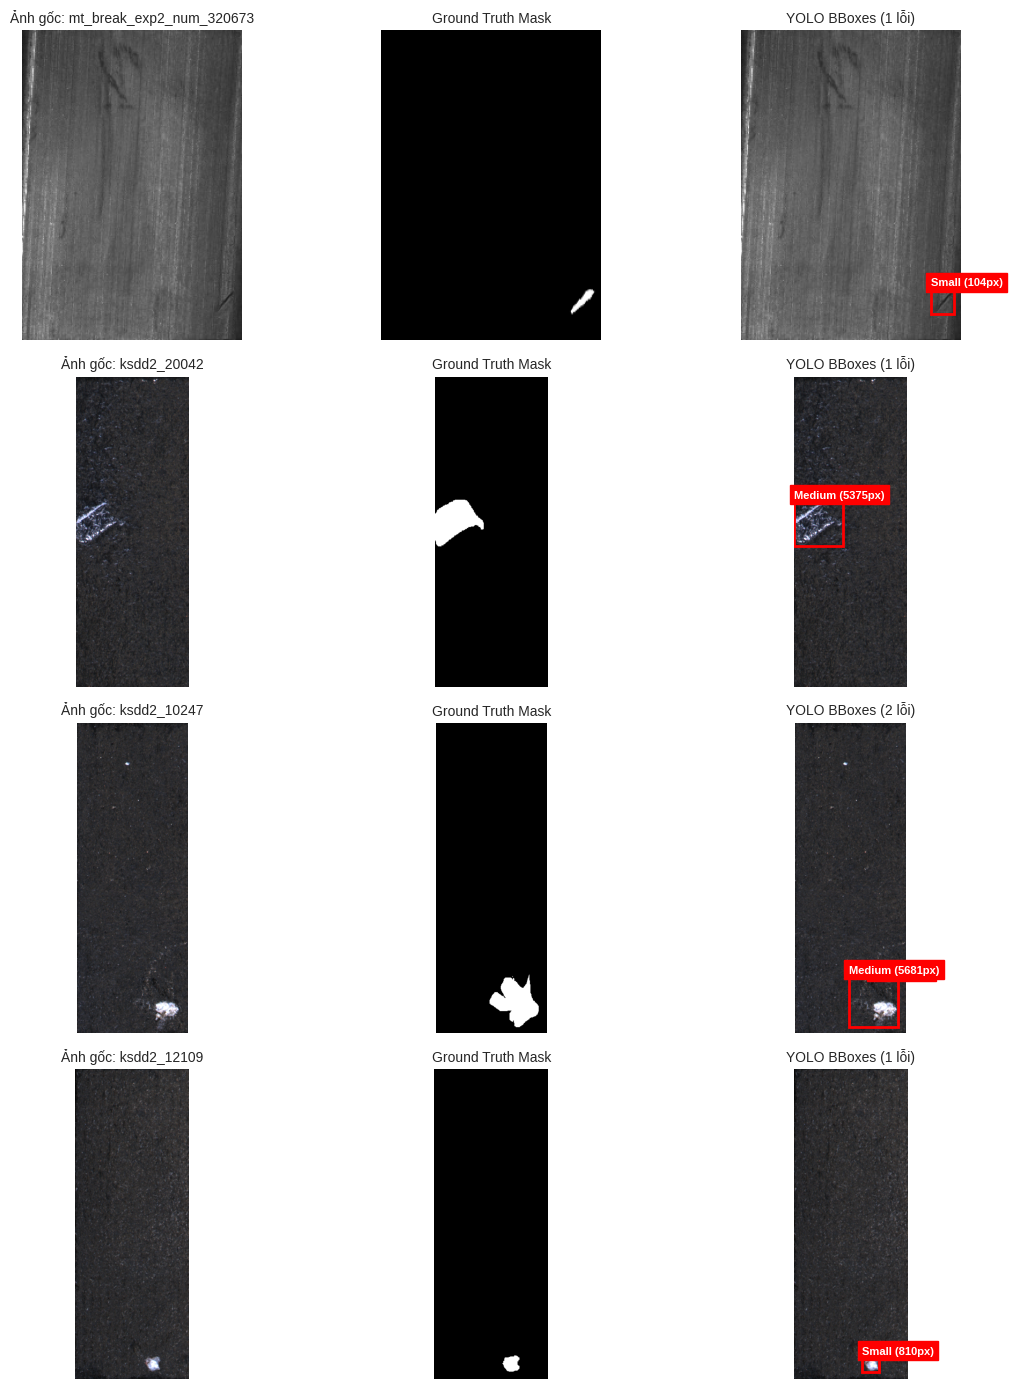

In [13]:
pos_samples = [s for s in unique_samples if s.has_defect and s.mask_path and s.mask_path.exists()]
selected = random.sample(pos_samples, min(4, len(pos_samples)))

fig, axes = plt.subplots(len(selected), 3, figsize=(12, 3.5 * len(selected)))
if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

for idx, s in enumerate(selected):
    img = Image.open(s.image_path).convert('RGB')
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"Ảnh gốc: {s.sample_id}", fontsize=10)
    axes[idx, 0].axis('off')

    mask = Image.open(s.mask_path).convert('L')
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title("Ground Truth Mask", fontsize=10)
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(img)
    for d in s.defects:
        rect = patches.Rectangle(
            (d.x_min, d.y_min), d.x_max - d.x_min, d.y_max - d.y_min,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        axes[idx, 2].add_patch(rect)
        axes[idx, 2].text(d.x_min, max(0, d.y_min - 4), f"{d.category} ({d.area_pixels}px)",
                          color='white', backgroundcolor='red', fontsize=8, fontweight='bold')
    axes[idx, 2].set_title(f"YOLO BBoxes ({len(s.defects)} lỗi)", fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_sample_defect_visualizations.png", dpi=300)
plt.show()

## 10. Phân chia Stratified Split (70% Train - 15% Val - 15% Test) & Xuất dữ liệu YOLO

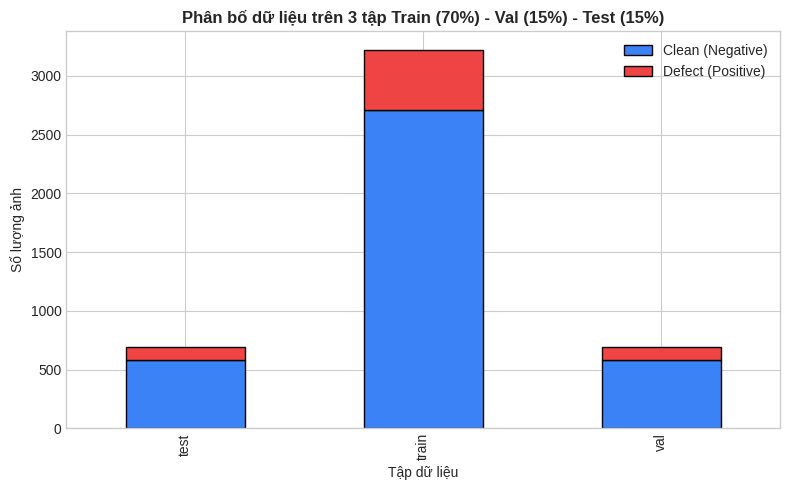

Bảng phân bổ chi tiết:
       Clean (Negative)  Defect (Positive)
split                                     
test                582                111
train              2707                510
val                 580                109


In [14]:
# Phân chia phân tầng
DatasetSplitter.split(unique_samples, train_r=0.7, val_r=0.15, test_r=0.15, seed=42)

split_map = {s.sample_id: s.split for s in unique_samples}
df['split'] = df['sample_id'].map(split_map)
df.to_csv(csv_out, index=False, encoding='utf-8-sig')

split_counts = df.groupby(['split', 'has_defect']).size().unstack(fill_value=0)
split_counts.columns = ['Clean (Negative)', 'Defect (Positive)']
split_counts.plot(kind='bar', stacked=True, color=['#3b82f6', '#ef4444'], figsize=(8, 5), edgecolor='black')
plt.title("Phân bố dữ liệu trên 3 tập Train (70%) - Val (15%) - Test (15%)", fontweight='bold')
plt.xlabel("Tập dữ liệu")
plt.ylabel("Số lượng ảnh")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_train_val_test_split.png", dpi=300)
plt.show()

print("Bảng phân bổ chi tiết:")
print(split_counts)